# Fase 2 - Calibración, distorsión y cadena de transformadas

Entradas:  `results/MH_01_easy/fase1_sync.npz` (salida de la Fase 1)
Salidas:   `results/MH_01_easy/fase2_calib.npz`

Al terminar esta fase tendrás cuatro cosas:

  1. Conversión píxel <-> coordenadas normalizadas, validada numéricamente.
  2. Imágenes rectificadas (para inspección) y su nueva K.
  3. `T_cam_imu` y la utilidad para invertir transformadas rígidas.
  4. La trayectoria del ground truth expresada en el frame de la CÁMARA,
     que es contra lo que compararás la odometría visual en la Fase 4.

El punto 4 es el que suele olvidarse: el GT de EuRoC son poses del IMU, y tu
odometría visual estima poses de la cámara. Comparar una con otra sin aplicar
la extrínseca introduce un error sistemático de ~7 cm.

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.transform import Rotation

In [2]:
def encontrar_raiz(marcador="data"):
    actual = Path.cwd().resolve()
    for candidato in [actual, *actual.parents]:
        if (candidato / marcador).is_dir():
            return candidato
    raise FileNotFoundError(f"No encuento '{marcador}/' hacia arriba desde {actual}")

In [3]:
RAIZ = encontrar_raiz()
ENTRADA = RAIZ / "results" / "MH_01_easy" / "fase1_sync.npz"
SALIDA = RAIZ / "results" / "MH_01_easy" / "fase2_calib.npz"

In [4]:
d = np.load(ENTRADA, allow_pickle=True)
K = d["K"]
dist = d["dist"]
T_imu_cam = d["T_imu_cam"]
rutas_img = d["rutas_img"]
t_cam_gt = d["t_cam_gt"]
gt_p_cam = d["gt_p_cam"]           # posición del IMU en world, en instantes de cámara
gt_q_cam_wxyz = d["gt_q_cam_wxyz"]  # orientación del IMU respecto a world

In [5]:
np.set_printoptions(precision=8, suppress=True)
print(f"K =\n{K}")
print(f"dist (k1,k2,p1,p2) = {dist}")

K =
[[458.654   0.    367.215]
 [  0.    457.296 248.375]
 [  0.      0.      1.   ]]
dist (k1,k2,p1,p2) = [-0.28340811  0.07395907  0.00019359  0.00001762]


## 2.1 - Utilidad: invertir una transformada rígida

Una transformada rígida 4x4 tiene estructura:

    T = [ R  t ]     con R ortonormal (R^T R = I) y det(R) = +1
        [ 0  1 ]

Su inversa NO se calcula con `np.linalg.inv`. Como R es ortonormal, R^-1 = R^T,
y la inversa tiene forma cerrada:

    T^-1 = [ R^T   -R^T·t ]
           [  0        1  ]

Es más rápido y numéricamente más estable: `inv` haría una factorización LU
genérica que puede introducir error donde no lo hay.
 

In [6]:
def invertir_transformada(T):
    """Inversa de una transformada rígida 4x4 usando la forma cerrada."""
    R, t = T[:3, :3], T[:3, 3]
    T_inv = np.eye(4)
    T_inv[:3, :3] = R.T
    T_inv[:3, 3] = -R.T @ t
    return T_inv

In [7]:
T_cam_imu = invertir_transformada(T_imu_cam)

# Comprobación: T · T^-1 debe ser la identidad.
assert np.allclose(T_imu_cam @ T_cam_imu, np.eye(4), atol=1e-12)

print("T_imu_cam (convierte puntos de CÁMARA a IMU):")
print(T_imu_cam)
print("\nT_cam_imu (convierte puntos de IMU a CÁMARA):")
print(T_cam_imu)

T_imu_cam (convierte puntos de CÁMARA a IMU):
[[ 0.01486554 -0.99988093  0.0041403  -0.02164015]
 [ 0.99955725  0.01496721  0.02571553 -0.06467699]
 [-0.02577444  0.00375619  0.99966073  0.00981073]
 [ 0.          0.          0.          1.        ]]

T_cam_imu (convierte puntos de IMU a CÁMARA):
[[ 0.01486554  0.99955725 -0.02577444  0.06522291]
 [-0.99988093  0.01496721  0.00375619 -0.02070639]
 [ 0.0041403   0.02571553  0.99966073 -0.0080546 ]
 [ 0.          0.          0.          1.        ]]


In [8]:
# La norma de la traslación se conserva al invertir; las componentes no.
print(f"\n|t| en T_imu_cam: {np.linalg.norm(T_imu_cam[:3, 3]) * 100:.2f} cm")
print(f"|t| en T_cam_imu: {np.linalg.norm(T_cam_imu[:3, 3]) * 100:.2f} cm  <- misma norma")
print(f"t de T_imu_cam = {T_imu_cam[:3, 3]}   (origen de CÁMARA visto desde IMU)")
print(f"t de T_cam_imu = {T_cam_imu[:3, 3]}   (origen de IMU visto desde CÁMARA)")


|t| en T_imu_cam: 6.89 cm
|t| en T_cam_imu: 6.89 cm  <- misma norma
t de T_imu_cam = [-0.02164015 -0.06467699  0.00981073]   (origen de CÁMARA visto desde IMU)
t de T_cam_imu = [ 0.06522291 -0.02070639 -0.0080546 ]   (origen de IMU visto desde CÁMARA)


In [9]:
# Ángulo de la rotación entre ambos frames, desde la traza:
#   traza(R) = 1 + 2·cos(theta)
angulo = np.degrees(np.arccos(np.clip((np.trace(T_imu_cam[:3, :3]) - 1) / 2, -1, 1)))
print(f"\nÁngulo entre frames cámara e IMU: {angulo:.2f}° (nominal 90°)")
print(f"Desalineamiento real del montaje: {abs(angulo - 90):.2f}°")


Ángulo entre frames cámara e IMU: 89.16° (nominal 90°)
Desalineamiento real del montaje: 0.84°


## 2.2 - Coordenadas normalizadas

El modelo pinhole proyecta un punto 3D en coordenadas de cámara (X,Y,Z) así:

    x = X/Z ,  y = Y/Z          <- coordenadas NORMALIZADAS (adimensionales)
    [aplicar distorsión]
    u = fu·x_d + cu ,  v = fv·y_d + cv    <- PÍXELES

La dirección normalizada -> píxel es una fórmula cerrada y exacta. La inversa
NO: el modelo Brown-Conrady no se puede invertir analíticamente, hay que
resolverlo numéricamente. Lo implementamos a mano para ver qué está pasando.


In [10]:
def distorsionar(xy):
    """
    Modelo Brown-Conrady (radial-tangencial). Fórmula cerrada, exacta.
    Entrada y salida en coordenadas normalizadas (N,2).
    """
    k1, k2, p1, p2 = dist
    x, y = xy[:, 0], xy[:, 1]
    r2 = x * x + y * y

    # Término radial: la lente desvía más los rayos cuanto más lejos del eje.
    radial = 1.0 + k1 * r2 + k2 * r2 * r2

    # Término tangencial: el sensor no está perfectamente paralelo a la lente.
    dx_tan = 2.0 * p1 * x * y + p2 * (r2 + 2.0 * x * x)
    dy_tan = p1 * (r2 + 2.0 * y * y) + 2.0 * p2 * x * y

    return np.column_stack([x * radial + dx_tan, y * radial + dy_tan])

In [11]:
def pixeles_a_normalizadas(uv, max_iter=100, tol=1e-14, verbose=False):
    """
    (N,2) píxeles distorsionados -> (N,2) coordenadas normalizadas ideales.

    Se resuelve por ITERACIÓN DE PUNTO FIJO. Buscamos (x,y) tal que
    distorsionar(x,y) = (x_d, y_d). Despejando de la fórmula del modelo:

        x <- (x_d - dx_tan(x,y)) / radial(x,y)
        y <- (y_d - dy_tan(x,y)) / radial(x,y)

    y se itera hasta converger. Es el mismo algoritmo que usa OpenVINS
    internamente. Nota: cv2.undistortPoints hace exactamente esto pero con
    5 iteraciones FIJAS y sin comprobar convergencia, lo que con esta lente
    (k1=-0.28, barril fuerte) deja ~0.3 px de error residual en las esquinas.
    """
    k1, k2, p1, p2 = dist
    uv = np.asarray(uv, dtype=np.float64).reshape(-1, 2)

    # Píxeles -> normalizadas distorsionadas (deshacer solo K, que es lineal).
    xd = (uv[:, 0] - K[0, 2]) / K[0, 0]
    yd = (uv[:, 1] - K[1, 2]) / K[1, 1]

    # Punto de partida: suponer que no hay distorsión.
    x, y = xd.copy(), yd.copy()

    for i in range(max_iter):
        r2 = x * x + y * y
        radial = 1.0 + k1 * r2 + k2 * r2 * r2
        dx_tan = 2.0 * p1 * x * y + p2 * (r2 + 2.0 * x * x)
        dy_tan = p1 * (r2 + 2.0 * y * y) + 2.0 * p2 * x * y

        x_nuevo = (xd - dx_tan) / radial
        y_nuevo = (yd - dy_tan) / radial

        # Criterio de parada: cuánto se ha movido la solución en esta iteración.
        cambio = np.max(np.abs(x_nuevo - x) + np.abs(y_nuevo - y))
        x, y = x_nuevo, y_nuevo
        if cambio < tol:
            break

    if verbose:
        print(f"  convergió en {i+1} iteraciones (cambio final = {cambio:.2e})")

    return np.column_stack([x, y])


In [12]:
def normalizadas_a_pixeles(xy):
    """(N,2) coordenadas normalizadas -> (N,2) píxeles distorsionados."""
    xy_d = distorsionar(np.asarray(xy, dtype=np.float64).reshape(-1, 2))
    return np.column_stack([K[0, 0] * xy_d[:, 0] + K[0, 2],
                            K[1, 1] * xy_d[:, 1] + K[1, 2]])

In [13]:
# VALIDACIÓN POR IDA Y VUELTA sobre una rejilla que cubre toda la imagen.
uu, vv = np.meshgrid(np.linspace(0, 751, 40), np.linspace(0, 479, 30))
rejilla = np.column_stack([uu.ravel(), vv.ravel()])

norm = pixeles_a_normalizadas(rejilla, verbose=True)
vuelta = normalizadas_a_pixeles(norm)
err = np.linalg.norm(vuelta - rejilla, axis=1)

print(f"Error de ida y vuelta píxel -> normalizada -> píxel:")
print(f"  medio  = {err.mean():.3e} px")
print(f"  máximo = {err.max():.3e} px")

  convergió en 30 iteraciones (cambio final = 8.10e-15)
Error de ida y vuelta píxel -> normalizada -> píxel:
  medio  = 6.940e-14 px
  máximo = 7.460e-13 px


In [14]:
# Comparación con el solver por defecto de OpenCV, para ver la diferencia.
norm_cv = cv2.undistortPoints(rejilla.reshape(-1, 1, 2), K, dist).reshape(-1, 2)
err_cv = np.linalg.norm(normalizadas_a_pixeles(norm_cv) - rejilla, axis=1)
print(f"\nMismo test con cv2.undistortPoints (5 iteraciones fijas):")
print(f"  medio  = {err_cv.mean():.3e} px")
print(f"  máximo = {err_cv.max():.3e} px")


Mismo test con cv2.undistortPoints (5 iteraciones fijas):
  medio  = 5.716e-02 px
  máximo = 2.913e-01 px


In [15]:
# El error del solver de 5 iteraciones se concentra en las esquinas, donde la
# distorsión es fuerte. Esto confirma que es un problema de convergencia.
radio = np.linalg.norm(rejilla - [K[0, 2], K[1, 2]], axis=1)
print(f"\nCorrelación error(OpenCV) vs radio: {np.corrcoef(radio, err_cv)[0,1]:.3f}")
for lo, hi in [(0, 100), (100, 200), (200, 300), (300, 500)]:
    m = (radio >= lo) & (radio < hi)
    if m.any():
        print(f"  radio {lo:3d}-{hi:3d} px: OpenCV={err_cv[m].max():.2e}  "
              f"nuestro={err[m].max():.2e}")

assert err.max() < 1e-9, "el roundtrip falla: revisa K o dist"


Correlación error(OpenCV) vs radio: 0.744
  radio   0-100 px: OpenCV=2.15e-08  nuestro=0.00e+00
  radio 100-200 px: OpenCV=2.03e-04  nuestro=2.84e-14
  radio 200-300 px: OpenCV=3.72e-02  nuestro=1.17e-13
  radio 300-500 px: OpenCV=2.91e-01  nuestro=7.46e-13


## 2.3 - Cuánto distorsiona esta lente

`k1 = -0.283` es negativo: distorsión de BARRIL. Vamos a medir el efecto en
píxeles, que es lo que importa en la práctica.

La comparación se hace contra la proyección pinhole PURA (sin distorsión):
para cada normalizada, dónde caería el píxel con y sin el modelo de distorsión.

In [16]:
pix_ideal = np.column_stack([K[0, 0] * norm[:, 0] + K[0, 2],
                             K[1, 1] * norm[:, 1] + K[1, 2]])
desplazamiento = np.linalg.norm(rejilla - pix_ideal, axis=1)

print(f"Desplazamiento por distorsión:")
print(f"  en el centro de la imagen: {desplazamiento[np.argmin(np.linalg.norm(rejilla - [376, 240], axis=1))]:.2f} px")
print(f"  medio en toda la imagen:   {desplazamiento.mean():.2f} px")
print(f"  máximo (esquinas):         {desplazamiento.max():.2f} px")

Desplazamiento por distorsión:
  en el centro de la imagen: 0.01 px
  medio en toda la imagen:   40.84 px
  máximo (esquinas):         170.59 px


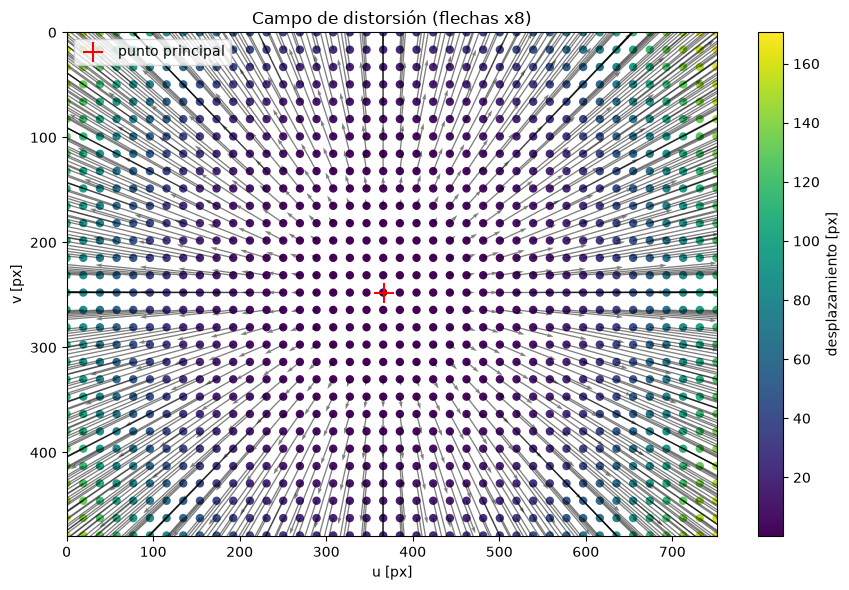

In [17]:
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(rejilla[:, 0], rejilla[:, 1], c=desplazamiento, s=25, cmap="viridis")
# Flechas x8 para que el efecto se vea; el patrón es radial desde el centro.
ax.quiver(rejilla[:, 0], rejilla[:, 1],
          (pix_ideal - rejilla)[:, 0], (pix_ideal - rejilla)[:, 1],
          angles="xy", scale_units="xy", scale=1 / 8, width=0.002, alpha=0.5)
plt.colorbar(sc, ax=ax, label="desplazamiento [px]")
ax.scatter([K[0, 2]], [K[1, 2]], c="r", marker="+", s=200, label="punto principal")
ax.set_xlim(0, 752); ax.set_ylim(480, 0)
ax.set_title("Campo de distorsión (flechas x8)")
ax.legend(); ax.set_xlabel("u [px]"); ax.set_ylabel("v [px]")
plt.tight_layout(); plt.show()

## 2.4 - Rectificar la imagen completa

Hay DOS formas de manejar la distorsión, y elegir bien importa:

  (A) RECTIFICAR LA IMAGEN entera y trabajar sobre la imagen corregida.
      Ventaja: puedes usar geometría pinhole pura directamente, y lo VES.
      Inconveniente: `remap` reinterpola todos los píxeles cada frame. Cuesta
      tiempo y suaviza la imagen, lo que degrada la precisión subpíxel del KLT.

  (B) TRACKEAR SOBRE LA IMAGEN CRUDA y rectificar solo los PUNTOS detectados.
      Es lo que hacen VINS-Mono y OpenVINS. Más rápido (rectificas ~200 puntos
      en vez de 360.000 píxeles) y sin pérdida de calidad de imagen.

EN EL PIPELINE USAREMOS (B). Aquí montamos (A) porque ver la imagen rectificada
es la mejor forma de convencerse de que la calibración es correcta.

`getOptimalNewCameraMatrix` devuelve una K NUEVA para la imagen rectificada.
Usar la K original sobre la imagen rectificada es un error clásico.
  alpha=0 -> recorta a la zona 100% válida: sin bordes negros, se pierde FOV.
  alpha=1 -> conserva todos los píxeles originales: aparecen bordes negros.

In [18]:
h, w = 480, 752
ALPHA = 0.0

In [21]:
K_new, roi = cv2.getOptimalNewCameraMatrix(K, dist, (w, h), ALPHA, (w, h))
mapa_x, mapa_y = cv2.initUndistortRectifyMap(K, dist, None, K_new, (w, h), cv2.CV_32FC1)

print(f"K original:\n{K}")
print(f"K rectificada (alpha={ALPHA}):\n{K_new}")
print(f"ROI válida: {roi}")
print(f"\nFocal: {K[0,0]:.1f} -> {K_new[0,0]:.1f} px "
      f"({100*(K_new[0,0]/K[0,0]-1):+.1f} %)")

K original:
[[458.654   0.    367.215]
 [  0.    457.296 248.375]
 [  0.      0.      1.   ]]
K rectificada (alpha=0.0):
[[356.3484715    0.         363.00427658]
 [  0.         418.19122261 250.27129706]
 [  0.           0.           1.        ]]
ROI válida: (0, 0, 751, 479)

Focal: 458.7 -> 356.3 px (-22.3 %)


In [22]:
# FOV horizontal antes y después, para cuantificar lo que se pierde con alpha=0.
fov = lambda f: 2 * np.degrees(np.arctan(w / (2 * f)))
print(f"FOV horizontal: {fov(K[0,0]):.1f}° -> {fov(K_new[0,0]):.1f}°")

FOV horizontal: 78.7° -> 93.1°


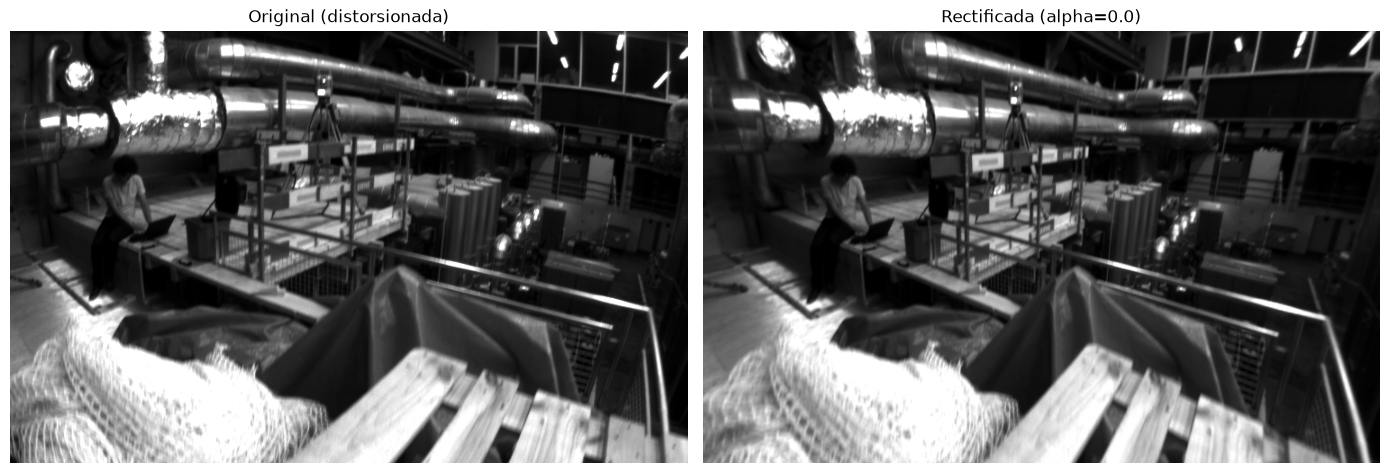

In [23]:
img = cv2.imread(str(rutas_img[100]), cv2.IMREAD_GRAYSCALE)
assert img is not None, f"no puedo leer {rutas_img[100]}"
img_rect = cv2.remap(img, mapa_x, mapa_y, cv2.INTER_LINEAR)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img, cmap="gray"); axes[0].set_title("Original (distorsionada)")
axes[1].imshow(img_rect, cmap="gray"); axes[1].set_title(f"Rectificada (alpha={ALPHA})")
for ax in axes:
    ax.axis("off")
plt.tight_layout(); plt.show()
 

## 2.5 - Validación visual: las rectas deben salir rectas

El criterio de que una calibración es correcta: cualquier línea recta del mundo
real debe proyectarse como línea recta en la imagen rectificada. En el machine
hall hay estructura metálica con aristas largas y rectas.

Se superpone una rejilla de referencia: en la imagen original las aristas se
curvan respecto a las líneas (sobre todo cerca de los bordes); en la
rectificada deben quedar paralelas a ellas.

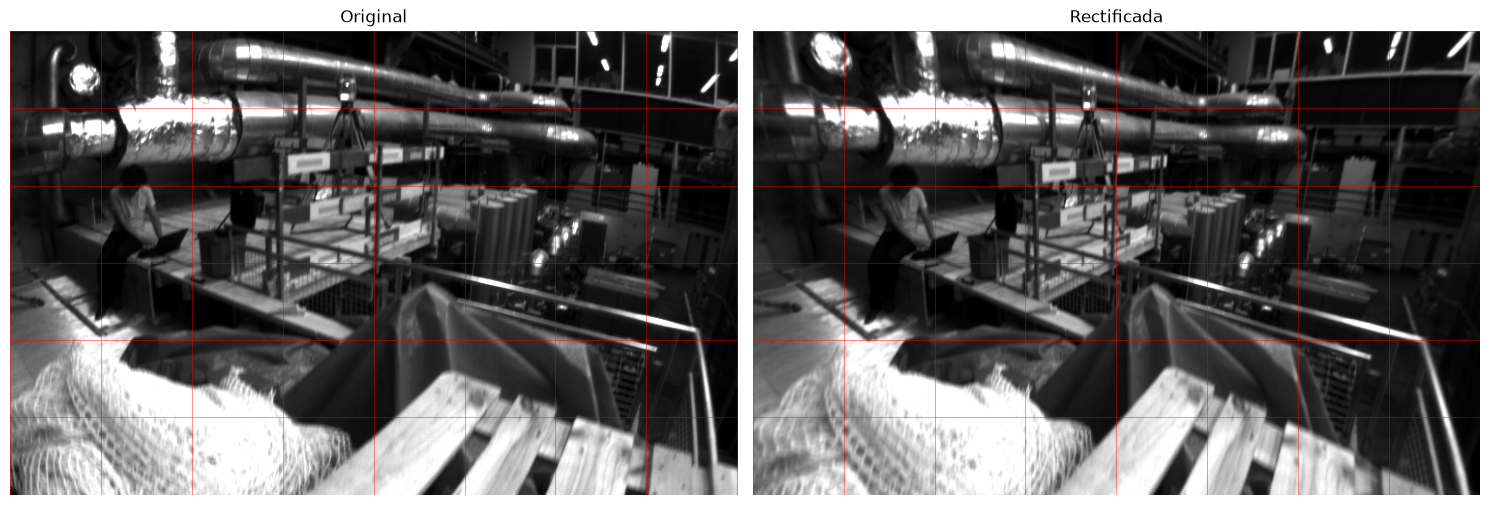

Mira las aristas metálicas cerca de los bordes de la imagen:
  - en la ORIGINAL se curvan hacia fuera (barril)
  - en la RECTIFICADA deben quedar rectas


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, im, titulo in [(axes[0], img, "Original"), (axes[1], img_rect, "Rectificada")]:
    ax.imshow(im, cmap="gray")
    for x in np.linspace(0, w - 1, 9):
        ax.axvline(x, color="r", lw=0.5, alpha=0.6)
    for y in np.linspace(0, h - 1, 7):
        ax.axhline(y, color="r", lw=0.5, alpha=0.6)
    ax.set_title(titulo); ax.axis("off")
plt.tight_layout(); plt.show()

print("Mira las aristas metálicas cerca de los bordes de la imagen:")
print("  - en la ORIGINAL se curvan hacia fuera (barril)")
print("  - en la RECTIFICADA deben quedar rectas")

## 2.6 - La cadena de transformadas

Tres frames en juego:

    WORLD  ---- T_world_imu (del GT) ----> IMU/BODY ---- T_imu_cam ----> CÁMARA

Regla de notación: `T_A_B` transforma puntos DESDE B HACIA A.

    p_A = T_A_B · p_B

Y se encadenan de forma que los subíndices interiores se cancelan:

    T_world_cam = T_world_imu · T_imu_cam

El GT da `T_world_imu`: `gt_p` es la posición del origen del IMU en world, y
`gt_q` la rotación que lleva vectores de IMU a world.

ESTO ES LO QUE NECESITAS EN LA FASE 4: tu odometría visual estimará poses de
CÁMARA. Compararlas contra `gt_p` (que son poses de IMU) mete un sesgo de ~7 cm.

In [25]:
def construir_T(R, t):
    """Ensambla una transformada 4x4 a partir de rotación 3x3 y traslación 3."""
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = t
    return T

In [27]:
# El GT viene en (w,x,y,z); scipy espera (x,y,z,w).
R_world_imu = Rotation.from_quat(gt_q_cam_wxyz[:, [1, 2, 3, 0]])

n = len(gt_p_cam)
T_world_cam = np.empty((n, 4, 4))
for i in range(n):
    T_wi = construir_T(R_world_imu[i].as_matrix(), gt_p_cam[i])
    T_world_cam[i] = T_wi @ T_imu_cam
 

In [28]:
# Posición de la cámara en world = columna de traslación de T_world_cam.
p_cam_world = T_world_cam[:, :3, 3]
 
sep = np.linalg.norm(p_cam_world - gt_p_cam, axis=1)
print(f"Separación entre trayectoria de IMU y de cámara:")
print(f"  media = {sep.mean()*100:.2f} cm")
print(f"  desviación = {sep.std()*100:.4f} cm")
print(f"  |t| de la extrínseca = {np.linalg.norm(T_imu_cam[:3,3])*100:.2f} cm  <- debe coincidir")

Separación entre trayectoria de IMU y de cámara:
  media = 6.89 cm
  desviación = 0.0000 cm
  |t| de la extrínseca = 6.89 cm  <- debe coincidir


In [29]:
# TEST CLAVE: la separación tiene que ser CONSTANTE e igual a |t| de la
# extrínseca. La cámara está rígidamente atornillada al IMU: la distancia entre
# ambos orígenes no puede cambiar con el tiempo. Si varía, el orden de
# multiplicación de las transformadas está mal.
assert np.allclose(sep, np.linalg.norm(T_imu_cam[:3, 3]), atol=1e-9), \
    "la separación IMU-cámara no es constante: revisa el orden de la cadena"
print("\nOK: separación constante -> la cadena de transformadas es correcta.")


OK: separación constante -> la cadena de transformadas es correcta.


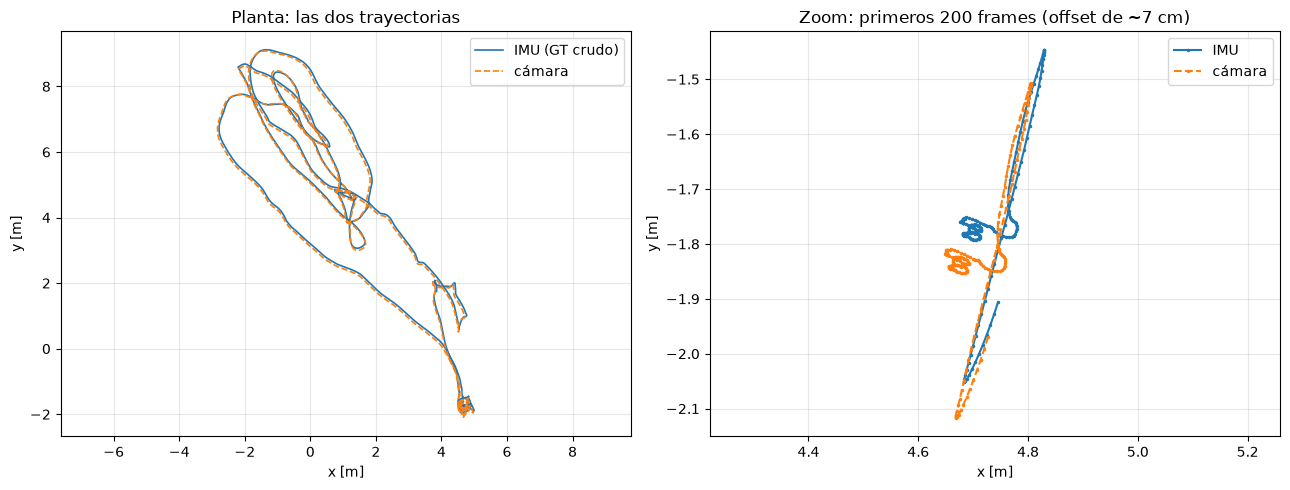

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(gt_p_cam[:, 0], gt_p_cam[:, 1], lw=1.2, label="IMU (GT crudo)")
axes[0].plot(p_cam_world[:, 0], p_cam_world[:, 1], lw=1.2, ls="--", label="cámara")
axes[0].set_xlabel("x [m]"); axes[0].set_ylabel("y [m]")
axes[0].set_title("Planta: las dos trayectorias")
axes[0].axis("equal"); axes[0].legend(); axes[0].grid(alpha=0.3)
 
# Zoom para ver que sí son curvas distintas, no la misma dibujada dos veces.
axes[1].plot(gt_p_cam[:200, 0], gt_p_cam[:200, 1], lw=1.5, marker=".", ms=3, label="IMU")
axes[1].plot(p_cam_world[:200, 0], p_cam_world[:200, 1], lw=1.5, marker=".", ms=3, ls="--", label="cámara")
axes[1].set_xlabel("x [m]"); axes[1].set_ylabel("y [m]")
axes[1].set_title("Zoom: primeros 200 frames (offset de ~7 cm)")
axes[1].axis("equal"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2.7 - Poses relativas del ground truth

La odometría visual de la Fase 4 no estima poses absolutas: estima el
movimiento RELATIVO entre frames consecutivos. Para poder compararlo, hace
falta el equivalente en el GT:

    T_rel(k) = T_cam(k)^-1 · T_cam(k+1)

es decir, la pose del frame k+1 vista desde el frame k.

La norma de su traslación es cuánto se movió la cámara entre dos frames. Ese
número es la referencia contra la que validarás la escala en la Fase 5: la VO
monocular te dará esa traslación con norma 1 (escala desconocida), y aquí
tienes el valor métrico real.

In [31]:
T_rel_gt = np.empty((n - 1, 4, 4))
for i in range(n - 1):
    T_rel_gt[i] = invertir_transformada(T_world_cam[i]) @ T_world_cam[i + 1]
 
desp_rel = np.linalg.norm(T_rel_gt[:, :3, 3], axis=1)
ang_rel = np.degrees(np.arccos(np.clip((np.trace(T_rel_gt[:, :3, :3], axis1=1, axis2=2) - 1) / 2, -1, 1)))

Movimiento entre frames consecutivos (dt = 50 ms):
  traslación:  media=2.21 cm  max=10.14 cm
  rotación:    media=0.52°  max=2.75°
  velocidad implícita: media=0.44 m/s  max=2.03 m/s


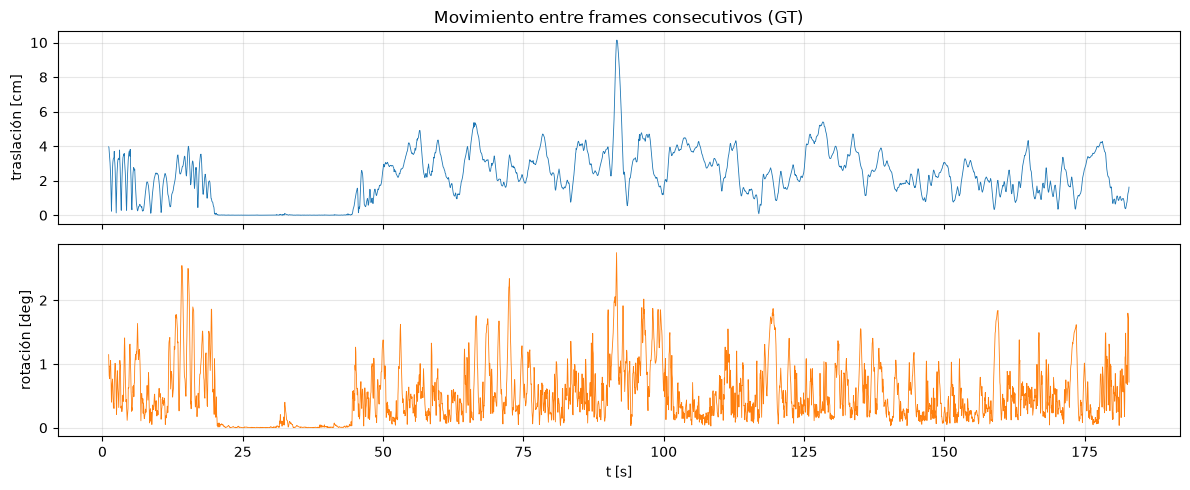

In [32]:
print(f"Movimiento entre frames consecutivos (dt = 50 ms):")
print(f"  traslación:  media={desp_rel.mean()*100:.2f} cm  max={desp_rel.max()*100:.2f} cm")
print(f"  rotación:    media={ang_rel.mean():.2f}°  max={ang_rel.max():.2f}°")
print(f"  velocidad implícita: media={desp_rel.mean()/0.05:.2f} m/s  max={desp_rel.max()/0.05:.2f} m/s")
 
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(t_cam_gt[:-1], desp_rel * 100, lw=0.6)
axes[0].set_ylabel("traslación [cm]"); axes[0].grid(alpha=0.3)
axes[0].set_title("Movimiento entre frames consecutivos (GT)")
axes[1].plot(t_cam_gt[:-1], ang_rel, lw=0.6, c="C1")
axes[1].set_ylabel("rotación [deg]"); axes[1].set_xlabel("t [s]"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2.8 - Guardar

In [33]:
SALIDA.parent.mkdir(parents=True, exist_ok=True)
np.savez_compressed(
    SALIDA,
    K=K, dist=dist, K_new=K_new, roi=np.array(roi),
    mapa_x=mapa_x, mapa_y=mapa_y,
    T_imu_cam=T_imu_cam, T_cam_imu=T_cam_imu,
    T_world_cam=T_world_cam, p_cam_world=p_cam_world,
    T_rel_gt=T_rel_gt, desp_rel=desp_rel, ang_rel=ang_rel,
    t_cam_gt=t_cam_gt,
)
print(f"Guardado en {SALIDA} ({SALIDA.stat().st_size / 1e6:.1f} MB)")

Guardado en C:\Users\ander\Documents\00-Proyectos\DRONdevoy\vio-euroc\results\MH_01_easy\fase2_calib.npz (3.2 MB)


## Test de aceptación de la Fase 2

**1. ¿Cuánto se desplaza un píxel de la esquina por efecto de la distorsión, y por qué eso rompería la geometría de la Fase 4 si lo ignoras?**

El número que buscas lo imprime tu celda 2.3, y para la esquina (0,0) sale ~163 px. El cálculo:

* píxel (0,0) → normalizadas distorsionadas: (-0.8006, -0.5431)
* resolviendo la inversa → normalizadas ideales: (-1.0960, -0.7435)
* proyección pinhole pura → (-135.5, -91.6)
* desplazamiento = √(135.5² + 91.6²) = 163 px

Y aquí una corrección mía: cuando te expliqué la calibración dije "unos 85-90 px en la esquina". Estaba calculando otra cosa — dónde cae un punto ideal situado al radio de la esquina, en vez de deshacer la distorsión del píxel de la esquina. El número bueno es 163 px, más del doble. 

Por qué rompe la Fase 4: la restricción epipolar x₂ᵀ E x₁ = 0 solo se cumple para coordenadas normalizadas ideales. Si le pasas coordenadas con 163 px de error sistemático en los bordes, las correspondencias no satisfacen la geometría epipolar y RANSAC hace una de dos cosas: descarta como outliers las features periféricas (que son justamente las de más paralaje y más información sobre la traslación), o converge a una E incorrecta. En ambos casos la pose sale mal.

**2. `T_imu_cam` convierte puntos de cámara a IMU. Si tienes un punto a 5 m delante de la cámara, ¿cuáles son sus coordenadas en el frame del IMU? (Calcúlalo: `T_imu_cam @ [0, 0, 5, 1]`.)**
```
T_imu_cam @ [0, 0, 5, 1] = [-0.0009, 0.0639, 5.0081]
```
Y no hace falta multiplicar la matriz entera. Como el punto es [0,0,5], solo interviene la tercera columna de R (multiplicada por 5) más la traslación:
```
5 · [0.0041, 0.0257, 0.9997] + [-0.0216, -0.0647, 0.0098]
```
Cómo leerlo:

La componente z sigue siendo ~5 m porque el eje óptico de la cámara y el eje z del IMU están casi alineados (recuerda: la rotación es de ~89° en torno a z, así que z apenas se toca).
Los 6.4 cm en y son la extrínseca: el punto está 5 m delante de la cámara, y la cámara está desplazada lateralmente respecto al IMU.

La distancia al IMU es 5.0085 m, no 5. Ese milímetro largo de diferencia es geometría real, no error numérico.

**3. ¿Por qué la separación entre la trayectoria del IMU y la de la cámara tiene que ser exactamente constante? ¿Qué habría fallado si variase?**

El motivo es físico, no numérico: la cámara está atornillada al IMU. Son un sólido rígido. La distancia entre sus dos orígenes es una constante mecánica que no puede cambiar mientras el dron vuela. Si tu código produce una separación variable, tu código está describiendo un dron que se deforma.

Qué falla concretamente si varía. El error típico es invertir el orden: escribir T_imu_cam @ T_world_imu en vez de T_world_imu @ T_imu_cam. La traslación resultante sería R_ic · p_wi + t_ic, y la separación respecto a p_wi valdría |R_ic·p_wi + t_ic − p_wi| — que depende de dónde esté el dron en la sala. Con el dron en [4.7, -1.8, 0.8] te daría metros de separación, y cambiaría a lo largo de la trayectoria.

Por eso ese assert es tan útil: detecta el error de orden sin que tengas que razonar sobre notación.

**4. ¿Por qué se usa `K_new` y no `K` sobre la imagen rectificada?**

La imagen rectificada es la imagen de otra cámara virtual: una pinhole perfecta, sin distorsión, con su propia focal y su propio punto principal. getOptimalNewCameraMatrix elige esos parámetros para que quepa el contenido rectificado.

K describe la cámara física real. K_new describe esa cámara virtual. Usar K sobre la imagen rectificada es afirmar que la relación píxel↔normalizada no ha cambiado, y con tus números ha cambiado un 22%.

Cuantifícalo: un punto en x = 0.5 normalizado.

* Con K: 458.654 · 0.5 + 367.215 = 596.5 px
* Con K_new: 356.348 · 0.5 + 363.004 = 541.2 px

55 px de error sistemático. Y es una escala mal aplicada, no un offset: te falsea directamente la profundidad estimada al triangular.

En nuestro pipeline K_new solo lo usarás para visualizar, porque rectificamos puntos y no imágenes. Pero si alguna vez trackeas sobre la imagen rectificada, esta es la trampa.

**5. ¿Cuánto se mueve la cámara entre dos frames consecutivos, de media? Ese número es tu referencia de escala para la Fase 5.** 

2.21 cm de media, y guarda también el pico de 10.14 cm — la VO monocular te dará esas traslaciones normalizadas a 1, y el cociente contra estos valores es el factor de escala que la IMU debe recuperar.